In [ ]:
include("../src/cbdata.jl")
include("../src/ASVGeometry.jl")
include("../src/clarity.jl")

using .CBOFSData, .ASVGeometry, .Clarity
using Dates, Statistics, Plots, JuMP, Ipopt, Revise, ProgressMeter

: 

In [ ]:
function optimize_lap_speeds_full_spatiotemporal(weights, N, ds, P_in_W_avg, alpha_decay, vehicle_params, sigma_val)
    model = Model(Ipopt.Optimizer)
    set_silent(model)
    
    # NEW 1: Compute the true spatial integral of the weights
    W_int = sum(weights) * ds 
    
    # Precompute the sensing matrix S[j, k]
    S_matrix = zeros(N, N)
    path_length = N * ds
    for j in 1:N
        for k in 1:N
            dist_direct = abs((j-1)*ds - (k-1)*ds)
            dist_wrap = path_length - dist_direct
            shortest_dist = min(dist_direct, dist_wrap)
            S_matrix[j, k] = exp(-(shortest_dist^2) / (2 * sigma_val^2))
        end
    end
    
    safe_u_min = max(0.1, vehicle_params.u_min) 
    
    # NEW 2: Remove the rigid u_max limit to allow sprinting. 
    # (We keep a tiny 1e-4 lower bound just to prevent divide-by-zero errors in Ipopt)
    @variable(model, 1e-4 <= dt[1:N] <= ds/safe_u_min)
    
    @variable(model, 0 <= q[1:N, 1:N+1] <= 1.0)
    
    @variable(model, T_lap >= 0)
    @constraint(model, T_lap == sum(dt[k] for k in 1:N))
    
    # NEW 3: Scale the J_avg limits using the spatial integral
    @variable(model, 0 <= J_avg <= W_int)
    
    # NEW 4: Multiply by `ds` inside the sum to properly integrate across space
    @NLconstraint(model, 
        J_avg * T_lap == sum( weights[j] * 0.5 * (q[j, k] + q[j, k+1]) * dt[k] * ds for j in 1:N, k in 1:N )
    )
    @objective(model, Max, J_avg)
    
    @variable(model, E_avail >= 0)
    @constraint(model, E_avail == P_in_W_avg * T_lap)
    
    # Power Budget (Restored to the proper inequality per your toy problem)
    @NLconstraint(model, 
        sum(vehicle_params.kh * dt[k] + vehicle_params.km * (ds^3 / dt[k]^2) for k in 1:N) <= E_avail
    )
    
    for k in 1:N
        k_next = (k == N) ? 1 : k + 1 
        for j in 1:N
            S_k = S_matrix[j, k]
            S_k_next = S_matrix[j, k_next]
            @NLconstraint(model, 
                q[j, k+1] == q[j, k] + 0.5 * dt[k] * (
                    (S_k * (1 - q[j, k])^2 - alpha_decay * q[j, k]^2) + 
                    (S_k_next * (1 - q[j, k+1])^2 - alpha_decay * q[j, k+1]^2)
                )
            )
        end
    end
    
    @constraint(model, [j=1:N], q[j, 1] == q[j, N+1])
    
    u_nominal = 0.5 * (safe_u_min + vehicle_params.u_max)
    set_start_value.(dt, ds / u_nominal)
    set_start_value(T_lap, N * ds / u_nominal)
    set_start_value.(q, 0.5)
    
    # NEW 5: Warm start scaled by the spatial integral
    set_start_value(J_avg, 0.5 * W_int)
    set_start_value(E_avail, P_in_W_avg * (N * ds / u_nominal))
    
    optimize!(model)
    
    if termination_status(model) in [MOI.LOCALLY_SOLVED, MOI.OPTIMAL]
        return ds ./ value.(dt) 
    else
        println("Warning: Optimizer failed. Defaulting to nominal speed.")
        return fill(vehicle_params.u_max, N) 
    end
end

optimize_lap_speeds_full_spatiotemporal (generic function with 1 method)

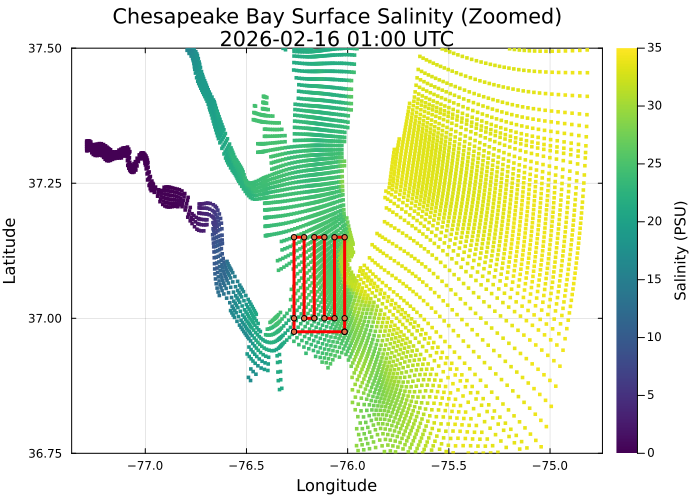

In [3]:
################### Transect Definition #######################################
# Start at the southeastern-most corner; southern return is offset by the same spacing (0.05°) as leg spacing
transect_lon = [
    -75.95, -75.95, -75.95,  # Start SE corner -> bottom of Leg 1 -> top of Leg 1
    -76.00, -76.00,          # Across top -> down Leg 2
    -76.05, -76.05,          # Across bottom -> up Leg 3
    -76.10, -76.10,          # Across top -> down Leg 4
    -76.15, -76.15,          # Across bottom -> up Leg 5
    -76.20, -76.20, -76.20,  # Across top -> down Leg 6 -> drop to southern return
    -75.95                   # Return east to close loop at start
]

t_lat_max = 37.05;
t_lat_min = 36.90;
t_lat_return = 36.875;  # Southern return line latitude

transect_lat = [
    t_lat_return, t_lat_min, t_lat_max,  # Start SE -> Leg 1 bottom -> Leg 1 top
    t_lat_max, t_lat_min,         # Leg 2 top -> Leg 2 bottom
    t_lat_min, t_lat_max,         # Leg 3 bottom -> Leg 3 top
    t_lat_max, t_lat_min,         # Leg 4 top -> Leg 4 bottom
    t_lat_min, t_lat_max,         # Leg 5 bottom -> Leg 5 top
    t_lat_max, t_lat_min, t_lat_return,  # Leg 6 top -> Leg 6 bottom -> southern return line
    t_lat_return                 # Close loop at SE start
]

# Shift path slightly west and north to avoid land overlap
lon_shift = -0.065   # west
lat_shift =  0.1  # north
transect_lon_shifted = transect_lon .+ lon_shift
transect_lat_shifted = transect_lat .+ lat_shift

lat_min, lat_max = 36.75, 37.5

### Load salinity data
frames = discover_files("./datafiles")

fr = frames[1]
lon_valid, lat_valid, salt_valid = load_surface_salinity(fr.file)
roi = (lat_valid .>= lat_min) .& (lat_valid .<= lat_max)

if any(roi)
    scatter(
        lon_valid[roi], lat_valid[roi],
        marker_z = salt_valid[roi],
        m = (1.8, :square, stroke(0)),
        c = :viridis,
        clims = (0, 35),
        colorbar = true,
        colorbar_title = "Salinity (PSU)",
        title = "Chesapeake Bay Surface Salinity (Zoomed)\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
        xlabel = "Longitude",
        ylabel = "Latitude",
        ylims = (lat_min, lat_max),
        legend = false,
        size = (700, 500),
        framestyle = :box,
        grid = true
    )

    plot!(
        transect_lon_shifted, transect_lat_shifted;
        lw = 3,
        lc = :red,
        marker = :circle,
        ms = 3,
        label = false
    )
else
    plot(
        transect_lon_shifted, transect_lat_shifted;
        title = "No ocean points in ROI\n$(Dates.format(fr.dt, dateformat"yyyy-mm-dd HH:MM")) UTC",
        xlabel = "Longitude",
        ylabel = "Latitude",
        ylims = (lat_min, lat_max),
        lw = 3,
        lc = :red,
        marker = :circle,
        ms = 3,
        legend = false,
        label = false
    )
end


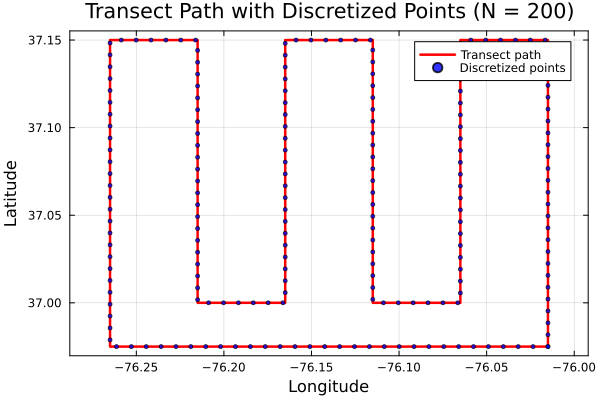

In [4]:
# Initialize ASV geometry and simulate path discretization
u_nominal = 1.75  # m/s
vehicle_params = VehicleParams(u_nominal, 24*3600.0)  # 24 hours at 1.75 m/s nominal speed

npts = 200
lon_path, lat_path, s_vec = discretize_polyline(transect_lon_shifted, transect_lat_shifted, npts)
path_length_m = s_vec[end]

plot(
    transect_lon_shifted, transect_lat_shifted;
    lw = 2.5,
    lc = :red,
    label = "Transect path",
    xlabel = "Longitude",
    ylabel = "Latitude",
    title = "Transect Path with Discretized Points (N = $npts)",
    legend = :topright,
    aspect_ratio = :equal,
    framestyle = :box,
    grid = true
)

scatter!(
    lon_path, lat_path;
    ms = 2.2,
    mc = :blue,
    alpha = 0.8,
    label = "Discretized points"
)

In [5]:
vehicle_params.u_min

0.0

## Optimizer Debugging


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



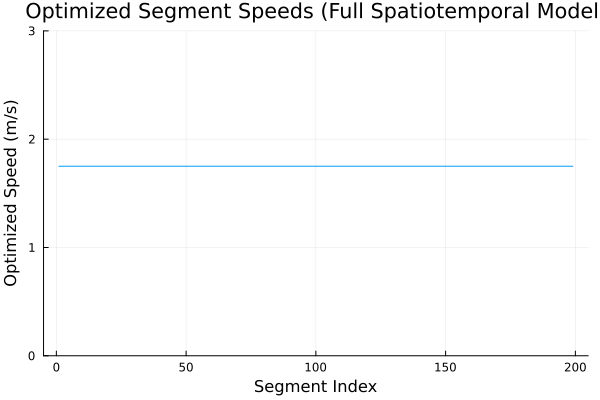

In [6]:
# Simulation parameters
dt_step_sec = 60.0              # 1 minute per step
sigma_val = 3000.0              # Sensing footprint [m]
alpha_val = 0.05                # Clarity decay

# NEW: Calculate Power Budget based on nominal baseline speed
power_nominal = vehicle_params.kh + vehicle_params.km * (u_nominal^3)
P_in_W = power_nominal          # Continuous Solar Power Generation [Watts]
# P_in_W = 750.0

# Path Discretization for JuMP
N_segments = npts - 1               # Number of path segments
ds = path_length_m / N_segments     # Length of each segment [m]

# Generate times (assuming frames are 1 hour apart, step every minute)
sim_times = collect(frames[1].dt : Minute(1) : frames[end].dt)
N_steps = length(sim_times)
current_weights = fill(1.0, npts)


# Run optimizer
u_opt_segments_full = optimize_lap_speeds_full_spatiotemporal(current_weights, N_segments, ds, P_in_W, alpha_val, vehicle_params, sigma_val)
plot(u_opt_segments_full, ylims=(0, vehicle_params.u_max * 1.2), xlabel="Segment Index", ylabel="Optimized Speed (m/s)", title="Optimized Segment Speeds (Full Spatiotemporal Model)", legend=false)

# Simulation Loop

In [7]:
# Simulation parameters
dt_step_sec = 60.0              # 1 minute per step
sigma_val = 3000.0              # Sensing footprint [m]
alpha_val = 0.05                # Clarity decay

# NEW: Calculate Power Budget based on nominal baseline speed
power_nominal = vehicle_params.kh + vehicle_params.km * (u_nominal^3)
P_in_W = power_nominal          # Continuous Solar Power Generation [Watts]
# P_in_W = 750.0

# Path Discretization for JuMP
N_segments = npts - 1               # Number of path segments
ds = path_length_m / N_segments     # Length of each segment [m]

# Generate times (assuming frames are 1 hour apart, step every minute)
sim_times = collect(frames[1].dt : Minute(1) : frames[end].dt)
N_steps = length(sim_times)

# Initial clarity state
clarity_state = zeros(Float64, npts)

# History Arrays
clarity_history    = zeros(Float64, npts, N_steps)
weights_history    = zeros(Float64, npts, N_steps)
salinity_meas_hist = zeros(Float64, N_steps)
lon_hist           = zeros(Float64, N_steps)
lat_hist           = zeros(Float64, N_steps)
battery_hist       = zeros(Float64, N_steps) 
lap_hist           = zeros(Int, N_steps)
speed_hist         = zeros(Float64, N_steps)

# Buffers for the current lap's measurements
lap_sal_buffer = Float64[]
lap_pos_buffer = Float64[]

s_robot_total = 0.0 
previous_lap = 1                       

# NEW: Battery Capacity Setup (e.g., capable of holding 24 hours of solar power)
# battery_capacity_Wh = P_in_W * 24.0 
battery_capacity_Wh = 6500.0
current_battery = battery_capacity_Wh 

# Helper functions
function get_2d_position(s_mod, s_vec, lon_path, lat_path)
    # Catch floating-point overflow at the end of the lap
    if s_mod >= s_vec[end]
        return lon_path[end], lat_path[end]
    end
    
    idx = findfirst(x -> x >= s_mod, s_vec)
    if idx === nothing || idx == 1
        return lon_path[1], lat_path[1]
    end
    
    s0, s1 = s_vec[idx-1], s_vec[idx]
    frac = (s_mod - s0) / (s1 - s0)
    lon_r = lon_path[idx-1] + frac * (lon_path[idx] - lon_path[idx-1])
    lat_r = lat_path[idx-1] + frac * (lat_path[idx] - lat_path[idx-1])
    return lon_r, lat_r
end

frame_times = [fr.dt for fr in frames]
frame_idx_for_time(t) = argmin(abs.(Dates.value.(frame_times .- t)))


# Run Initial Optimization for Lap 1 (Uniform weights)
# low_w  = 0.2
# high_w = 1.0

# s_start = (4/8) * path_length_m
# s_end   = (6/8) * path_length_m

# current_weights = fill(low_w, npts)
# current_weights[(s_vec .>= s_start) .& (s_vec .<= s_end)] .= high_w
current_weights = fill(1.0, npts)
u_opt_segments = optimize_lap_speeds_full_spatiotemporal(current_weights, N_segments, ds, P_in_W, alpha_val, vehicle_params, sigma_val)


# ==============================================================================
# 4. MAIN SIMULATION LOOP
# ==============================================================================
println("Starting Optimized Variable-Speed Simulation Loop...")

@showprogress 1 "Running Sim..." for (t_idx, t) in enumerate(sim_times)
    
    # --- A. Determine Lap & Position ---
    current_lap = floor(Int, s_robot_total / path_length_m) + 1
    s_mod = mod(s_robot_total, path_length_m) 
    
    # --- B. LAP TRANSITION LOGIC ---
    if current_lap > previous_lap
        # 1. Calculate new weights from the lap that just finished
        current_weights = calculate_target_weights(lap_sal_buffer, lap_pos_buffer, s_vec, npts)
        
        # 2. Run Optimization for the new lap 
        u_opt_segments = optimize_lap_speeds_full_spatiotemporal(current_weights, N_segments, ds, P_in_W, alpha_val, vehicle_params, sigma_val)
        
        # 3. Clear buffers for the new lap
        empty!(lap_sal_buffer)
        empty!(lap_pos_buffer)
        
        previous_lap = current_lap
    end
    
    # --- C. Environmental Lookup & Buffering ---
    # Sample salinity once at the start of the 60-second frame
    lon_r, lat_r = get_2d_position(s_mod, s_vec, lon_path, lat_path)
    frame_idx = frame_idx_for_time(t)
    lon_v, lat_v, salt_v = load_surface_salinity(frames[frame_idx].file) 
    s_meas = sample_salinity(lon_r, lat_r, lon_v, lat_v, salt_v)
    
    push!(lap_sal_buffer, s_meas)
    push!(lap_pos_buffer, s_mod)

    # =====================================================================
    # --- D. COMBINED HIGH-RESOLUTION PHYSICS SWEEP ---
    # (Absorbs previous Sections C, E, F, and H)
    # =====================================================================
    inner_dt = 0.25 # Finer time steps for accurate ODE integration & physics
    t_inner = 0.0
    R_earth = 6371000.0
    
    # Use the true array length to prevent wrap-around coordinate teleports
    path_length_true = s_vec[end]
    
    # Local trackers for the continuous 60-second sweep
    s_t = s_robot_total
    bat_t = current_battery
    u_current_display = 0.0
    
    while t_inner < dt_step_sec
        dt_inc = min(inner_dt, dt_step_sec - t_inner)
        
        # 1. Exact position modulo true path length
        s_t_mod = mod(s_t, path_length_true)
        
        # 2. DYNAMIC SPEED LOOKUP (Fixes the battery desync)
        # Evaluated every 0.25s, so the robot changes speed the millisecond it crosses a segment!
        seg_idx = min(floor(Int, s_t_mod / ds) + 1, N_segments)
        u_opt = u_opt_segments[seg_idx]
        
        # 3. HIGH-RES BATTERY PHYSICS (Constant Power, Unbounded Capacity)
        energy_gained_Wh = P_in_W * (dt_inc / 3600.0)
        
        power_req_opt = vehicle_params.kh + vehicle_params.km * (u_opt^3)
        energy_req_opt_Wh = power_req_opt * (dt_inc / 3600.0)
        
        # Check if we have enough battery to maintain optimal speed
        if bat_t + energy_gained_Wh >= energy_req_opt_Wh
            u_current = u_opt
            bat_t = bat_t + energy_gained_Wh - energy_req_opt_Wh
        else
            # Stall out if budget is blown (should rarely happen with the equality constraint)
            u_current = 0.0
            energy_idle_Wh = vehicle_params.kh * (dt_inc / 3600.0)
            if bat_t + energy_gained_Wh >= energy_idle_Wh
                bat_t = bat_t + energy_gained_Wh - energy_idle_Wh
            else
                bat_t = 0.0 # Floor it at zero so we don't get negative energy
            end
        end
        
        # REMOVED: bat_t = min(battery_capacity_Wh, bat_t)
        # The battery can now buffer as much energy as it needs to without artificially capping
        u_current_display = u_current
        
        # 4. CLARITY SWEEP 
        lon_t, lat_t = get_2d_position(s_t_mod, s_vec, lon_path, lat_path)
        lat_t_rad = deg2rad(lat_t)
        cos_lat_t = cos(lat_t_rad)
        
        for j in 1:npts
            dx = deg2rad(lon_path[j] - lon_t) * R_earth * cos_lat_t
            dy = deg2rad(lat_path[j] - lat_t) * R_earth
            dist_meters = sqrt(dx^2 + dy^2)
            
            Sj_current = sensing_function(dist_meters; S_0 = 1.0, sigma = sigma_val)
            clarity_state[j] = update_clarity_rk4(clarity_state[j], Sj_current, dt_inc; alpha=alpha_val)
        end
        
        # 5. MOVE ROBOT 
        s_t += u_current * dt_inc
        t_inner += dt_inc
    end
    
    # Sync local variables back to the main loop state at the end of the 60s
    s_robot_total = s_t
    current_battery = bat_t
    u_current = u_current_display # Pass out the final speed for logging
    
    # --- E. Log Everything ---
    clarity_history[:, t_idx]  = clarity_state
    weights_history[:, t_idx]  = current_weights
    salinity_meas_hist[t_idx]  = s_meas
    lon_hist[t_idx]            = lon_r
    lat_hist[t_idx]            = lat_r
    battery_hist[t_idx]        = current_battery 
    lap_hist[t_idx]            = current_lap
    speed_hist[t_idx]          = u_current
end

Starting Optimized Variable-Speed Simulation Loop...


Running Sim... 100%|█████████████████████████████████████| Time: 0:33:00Running Sim...  79%|██████████████████████████████       |  ETA: 0:07:18


Total Accumulated Clarity (All Time): 324622.43
Lap 1 Total Clarity: 62580.16
Lap 2 Total Clarity: 285615.2
Mean Salinity Deviation: -2.63 PSU
Standard Deviation of Salinity Deviation: 2.02 PSU


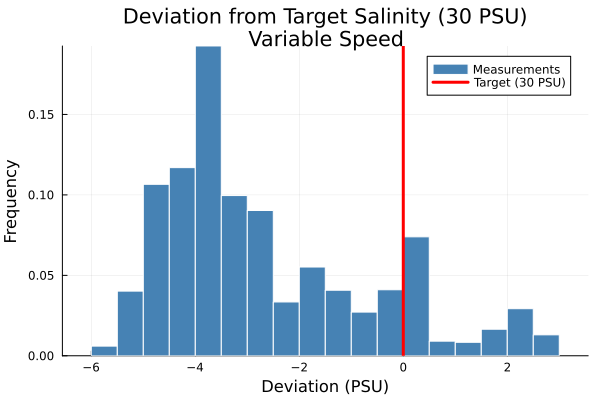

In [8]:
# --- Analytics 1: Total Clarity ---
# Total clarity accumulated across all points and all times
total_clarity = sum(weights_history .* clarity_history)
println("Total Accumulated Clarity (All Time): ", round(total_clarity, digits=2))

# --- Analytics 2: Per-Lap Clarity ---
total_laps = lap_hist[end]
lap_clarity = zeros(Float64, total_laps)

for lap in 1:total_laps
    # Find all time indices belonging to this lap
    idx_for_lap = findall(x -> x == lap, lap_hist)
    # Sum the clarity matrix just for those time columns
    lap_clarity[lap] = sum(clarity_history[:, idx_for_lap])
    println("Lap $lap Total Clarity: ", round(lap_clarity[lap], digits=2))
end

# --- Analytics 3: Salinity Deviation Histogram ---
target_salinity = 30.0
# Calculate the deviation (Measurement - Target)
salinity_deviation = salinity_meas_hist .- target_salinity

println("Mean Salinity Deviation: ", round(mean(salinity_deviation), digits=2), " PSU")
println("Standard Deviation of Salinity Deviation: ", round(std(salinity_deviation), digits=2), " PSU")

# Plot the Histogram
histogram(
    salinity_deviation,
    bins = 30,
    normalize = :probability,
    title = "Deviation from Target Salinity (30 PSU)\nVariable Speed",
    xlabel = "Deviation (PSU)",
    ylabel = "Frequency",
    label = "Measurements",
    color = :steelblue,
    linecolor = :white,
    grid = true,
    size = (600, 400)
)
# Add a vertical line at 0 (Target)
vline!([0.0], lw=3, color=:red, label="Target (30 PSU)")
savefig("variable_speed_salinity_deviation_histogram.png")
plot!()

In [9]:
nsteps = length(sim_times)
@assert nsteps > 0 "No simulation history found. Run the simulation cell first."

# Keep video length manageable (e.g., skip frames if the simulation is days long)
frame_stride = max(1, fld(nsteps, 300)) # Targets around ~300 frames total
frame_ids = 1:frame_stride:nsteps

lat_min, lat_max = 36.75, 37.5
lon_pad, lat_pad = 0.02, 0.02
xlims_map = (minimum(lon_path) - lon_pad, maximum(lon_path) + lon_pad)
ylims_map = (lat_min - lat_pad, lat_max + lat_pad)
bmax = max(maximum(battery_hist), 1.0)

smin = minimum(salinity_meas_hist)
smax = maximum(salinity_meas_hist)
spad = max(0.5, 0.05 * max(smax - smin, eps()))
target_salinity = 30.0

# Simple cache so we don't reload the NetCDF file 60 times for the same hour
sal_cache = Dict{String, Tuple{Vector{Float64}, Vector{Float64}, Vector{Float64}}}()

# --- 3. Animation Loop ---

anim = @animate for k in frame_ids
    lon_r, lat_r = lon_hist[k], lat_hist[k]
    
    # Track history up to current frame
    tr_lon = lon_hist[1:k]
    tr_lat = lat_hist[1:k]

    # Salinity background for current time
    fr = frames[frame_idx_for_time(sim_times[k])]
    if !haskey(sal_cache, fr.file)
        sal_cache[fr.file] = load_surface_salinity(fr.file)
    end
    lon_v, lat_v, salt_v = sal_cache[fr.file]
    
    # Filter background to ROI to speed up plotting
    roi = (lon_v .>= xlims_map[1]) .& (lon_v .<= xlims_map[2]) .&
          (lat_v .>= ylims_map[1]) .& (lat_v .<= ylims_map[2])
    idx = findall(roi)
    
    # Subsample background if it's too dense
    if length(idx) > 12000
        step_val = cld(length(idx), 12000)
        idx = idx[1:step_val:end]
    end

    # --- Panel 1: Boat position with salinity background ---
    p1 = scatter(
        lon_v[idx], lat_v[idx];
        marker_z = salt_v[idx],
        m = (2.0, :square, stroke(0)),
        c = :viridis, clims = (0, 35),
        colorbar = true, colorbar_title = "Salinity (PSU)",
        xlabel = "Longitude", ylabel = "Latitude",
        title = "Boat + Salinity\n$(Dates.format(sim_times[k], dateformat"yyyy-mm-dd HH:MM")) UTC | Lap $(lap_hist[k])",
        aspect_ratio = :equal, xlims = xlims_map, ylims = ylims_map,
        framestyle = :box, grid = true, legend = :bottomleft
    )
    plot!(p1, transect_lon_shifted, transect_lat_shifted; lw = 2.5, lc = :white, label = "Planned Path")
    plot!(p1, tr_lon, tr_lat; lw = 2, lc = :dodgerblue, label = "Track")
    scatter!(p1, [lon_r], [lat_r]; ms = 6, mc = :red, label = "Boat")

    # --- Panel 2: Clarity (Using continuous line instead of scatter) ---
    p2 = plot(
        lon_path, lat_path;
        line_z = clarity_history[:, k],   # Changed from marker_z
        linewidth = 6,                    # Set how thick you want the path
        c = :plasma, clims = (0, 1),
        colorbar = true, colorbar_title = "Clarity",
        xlabel = "Longitude", ylabel = "Latitude",
        title = "Clarity Map (Path Points)",
        aspect_ratio = :equal, xlims = xlims_map, ylims = ylims_map,
        legend = false, framestyle = :box, grid = true
    )
    
    # We still use scatter! for the robot itself, since it's just one point
    scatter!(p2, [lon_r], [lat_r]; ms = 6, mc = :white, msw = 0, label = false)
    
    # --- Panel 3: Battery vs time ---
    p3 = plot(
        sim_times[1:k], battery_hist[1:k];
        lw = 2.5, lc = :seagreen4,
        xlabel = "Time", ylabel = "Battery (Wh)",
        title = "Battery vs Time",
        ylims = (0, 1.05 * bmax),
        xlims = (sim_times[1], sim_times[end]), # Fix X axis so it doesn't jump around
        legend = false, framestyle = :box, grid = true
    )

    # --- Panel 4: Measured salinity vs time ---
    p4 = plot(
        sim_times[1:k], salinity_meas_hist[1:k];
        lw = 2.5, lc = :darkorange,
        xlabel = "Time", ylabel = "Measured Salinity (PSU)",
        title = "Measured Salinity vs Time",
        ylims = (smin - spad, smax + spad),
        xlims = (sim_times[1], sim_times[end]), # Fix X axis
        legend = :topright, framestyle = :box, grid = true,
        label = "Measured"
    )
    hline!(p4, [target_salinity]; lc = :red, ls = :dash, lw = 1.5, label = "Target")

    # Combine into a 2x2 grid
    plot(p1, p2, p3, p4; layout = (2, 2), size = (1500, 900))
end

mp4(anim, "variable_speed_results.mp4"; fps = 15)

[ Info: Saved animation to c:\Users\kavin\OneDrive\Research\CPS\cdc26_ive_intro\code\chesapeake_bay\variable_speed_results.mp4


Plots.AnimatedGif("c:\\Users\\kavin\\OneDrive\\Research\\CPS\\cdc26_ive_intro\\code\\chesapeake_bay\\variable_speed_results.mp4")

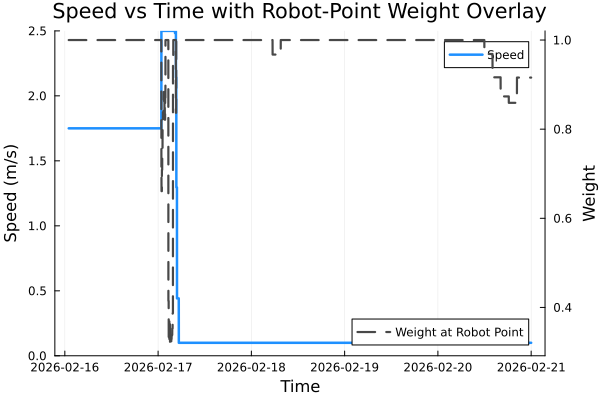

In [10]:
# Weight of the path point closest to the robot at each time step
nsteps = length(sim_times)
robot_point_idx = Vector{Int}(undef, nsteps)
weight_at_robot = Vector{Float64}(undef, nsteps)

for k in 1:nsteps
    d2 = (lon_path .- lon_hist[k]).^2 .+ (lat_path .- lat_hist[k]).^2
    idx = argmin(d2)
    robot_point_idx[k] = idx
    weight_at_robot[k] = weights_history[idx, k]
end

# Plot speed and overlaid weight (secondary y-axis)
p = plot(
    sim_times, speed_hist;
    lw = 2.5, lc = :dodgerblue,
    xlabel = "Time",
    ylabel = "Speed (m/s)",
    title = "Speed vs Time with Robot-Point Weight Overlay",
    label = "Speed",
    framestyle = :box,
    grid = true,
    legend = :topright,
    ylims = (0, 2.5)
)

plot!(
    twinx(), sim_times, weight_at_robot;
    lw = 2.2, lc = :crimson, ls = :dash,
    ylabel = "Weight",
    label = "Weight at Robot Point"
)
savefig("speed_weight_overlay.png")
plot!()

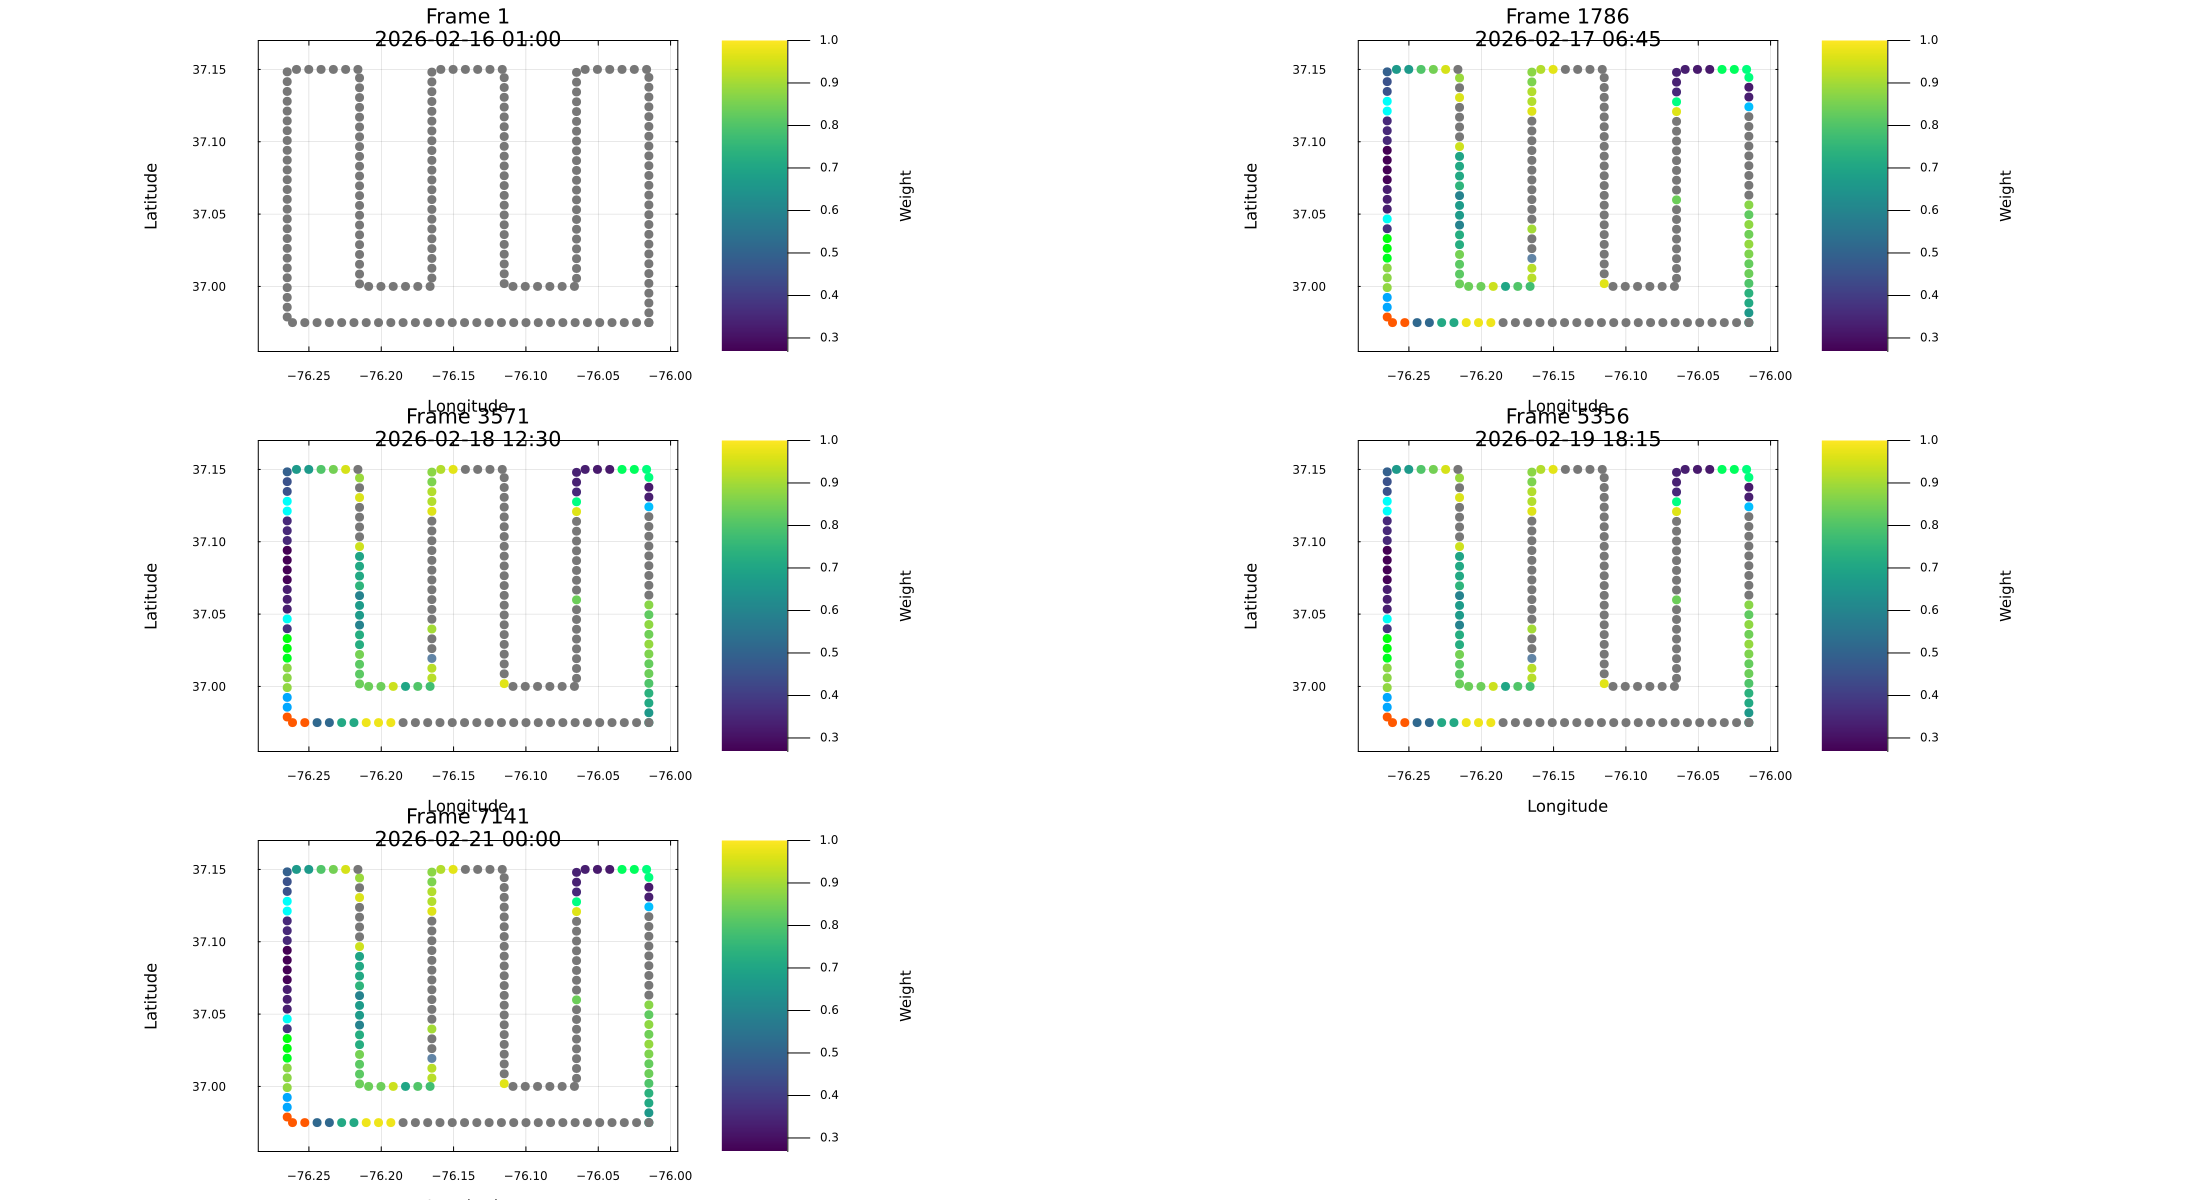

In [11]:
# Show weight distribution on path points for 5 evenly spaced frames
nsteps = length(sim_times)
@assert nsteps >= 5 "Need at least 5 time steps in weights_history."

frame_ids = unique(round.(Int, range(1, nsteps, length=5)))

xlims_map = (minimum(lon_path) - 0.02, maximum(lon_path) + 0.02)
ylims_map = (minimum(lat_path) - 0.02, maximum(lat_path) + 0.02)

wmin = minimum(weights_history)
wmax = maximum(weights_history)

plots = Plots.Plot[]
for k in frame_ids
    p = scatter(
        lon_path, lat_path;
        marker_z = weights_history[:, k],
        m = (5, :circle, stroke(0)),
        c = :viridis,
        clims = (wmin, wmax),
        colorbar = true,
        colorbar_title = "Weight",
        title = "Frame $k\n$(Dates.format(sim_times[k], dateformat"yyyy-mm-dd HH:MM"))",
        xlabel = "Longitude",
        ylabel = "Latitude",
        aspect_ratio = :equal,
        xlims = xlims_map,
        ylims = ylims_map,
        legend = false,
        framestyle = :box,
        grid = true
    )
    push!(plots, p)
end

plot(plots...; layout = (3, 2), size = (2200, 1200))